# Cyber Detection Pipeline — VERSION FINALE
### CIC Trap4Phish 2025 | Production-Ready | Consolidation v1→v10

---

## Ce que contient cette version finale

Ce notebook consolide **10 versions** de développement en ne gardant que ce qui fonctionne.
Chaque cellule est justifiée par des mesures réelles, pas des estimations.

---

## Résultats finaux mesurés (test set, jamais vu pendant l'entraînement)

| Modèle | AUC | F1 (opt) | P@R≥95% | ECE | Latence | Signal |
|--------|-----|----------|---------|-----|---------|--------|
| **LightGBM HTML + Platt** | **0.9875** | **0.9455** | **0.9369** | **0.0317** | **0.86ms** | Structural |
| LightGBM 5-fold CV | 0.9855 ± 0.0023 | — | — | — | — | IC 95%: [0.981, 0.990] |
| TF-IDF word+char + Platt | 0.9789 | 0.8960 | 0.7822 | 0.0756 | 0.16ms | Textuel |
| DistilBERT v9 | 0.9795 | 0.9050 | — | — | ~4ms GPU | Séman. |
| MobileBERT v9 | 0.9744 | 0.8720 | — | — | ~58ms CPU | Séman. |

**Recommandation déploiement :**
- **Prod temps réel (<1ms)** : LightGBM + Platt — meilleur AUC, meilleure calibration, plus rapide
- **Prod GPU disponible** : LightGBM + DistilBERT (fusion), AUC estimé ~0.990
- **Edge / CPU only** : TF-IDF + Platt — 0.16ms, AUC=0.979, ECE=0.076

---

## Problèmes résolus v1→vFINALE

| Bug | Découvert | Fix |
|-----|-----------|-----|
| `file_path` encode `/Malicious/` | v1 | Supprimé au chargement |
| `macro_present` r=0.9997 (Word) | v1 | Feature supprimée |
| QR CSV non chargé (`\a`→Bell) | v2 | `Path()` cross-platform |
| Split QR aléatoire = leakage URL | v2 | SHA-256 hash split |
| `CalibratedClassifierCV` crash LGB | v4 | Platt scaling manuel scipy |
| `dde_present` logique inversée | v1 | Documenté + supprimé |
| `label == 'malicious'` sur CSV int | v9 | `.astype(int)` |
| PSI référence = train (artefact) | v9 | Référence = val set |
| MAX_CHARS=3000 tronquait tout | v8 | MAX_CHARS=8000 |
| MobileBERT 3 epochs (sous-entraîné) | v8 | 5 epochs + warmup=200 |
| Fusion LGB ignoré (poids=-0.025) | v10 | LGB non inclus dans fusion |


## Cellule 1 — Imports & Configuration

In [1]:
import os, re, math, json, hashlib, warnings, joblib, time
from pathlib import Path
from collections import Counter
from urllib.parse import urlparse, parse_qs
from scipy.special import expit
from scipy.optimize import minimize
from scipy.sparse import hstack
from scipy.stats import ks_2samp

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import (StratifiedShuffleSplit, StratifiedKFold,
    cross_val_score, cross_val_predict)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import calibration_curve   # sklearn >= 1.0
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, average_precision_score, brier_score_loss)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance

import lightgbm as lgb
import xgboost as xgb
import shap

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    BERT_OK = True
except ImportError:
    BERT_OK = False
    print("pip install transformers  — requis pour DistilBERT/MobileBERT")

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {DEVICE}")
if DEVICE.type == 'cuda':
    g = torch.cuda.get_device_properties(0)
    print(f"  GPU   : {g.name}  |  VRAM : {g.total_memory/1e9:.1f} GB")
    torch.backends.cuda.matmul.allow_tf32 = True

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

OUTPUT = Path('./models_final')
OUTPUT.mkdir(exist_ok=True)

print(f"\nsklearn  : {__import__('sklearn').__version__}")
print(f"lightgbm : {lgb.__version__}")
print(f"xgboost  : {xgb.__version__}")
print(f"Output   : {OUTPUT.resolve()}")


Device  : cuda
  GPU   : NVIDIA GeForce RTX 5070 Ti Laptop GPU  |  VRAM : 12.8 GB

sklearn  : 1.8.0
lightgbm : 4.6.0
xgboost  : 3.2.0
Output   : C:\Users\karim\Documents\CIC\models_final


## Cellule 2 — Chemins & Constantes

In [2]:
BASE_DIR = Path(__file__).resolve().parent if "__file__" in locals() else Path(".")

# Point d'entrée principal des données (Configurable via variable d'environnement, sinon local)
DATA = Path(os.getenv("CIC_DATA_DIR", BASE_DIR))

# 1. Gestion des sous-dossiers spécifiques pour les formats bureautiques/web
FINAL_CSV_DIR = DATA / "Final CSV"
SUB_DIRS = {
    "pdf": FINAL_CSV_DIR / "PDF",
    "html": FINAL_CSV_DIR / "HTML",
    "word": FINAL_CSV_DIR / "Word",
    "excel": FINAL_CSV_DIR / "Excel"
}


# CSV features statiques (labels = 0/1 entiers)
CSV = {
    "pdf": SUB_DIRS["pdf"] / "PDF_All_features.csv",
    "html": SUB_DIRS["html"] / "HTML_All_Features.csv",
    "word": SUB_DIRS["word"] / "Word_All_features.csv",
    "excel": SUB_DIRS["excel"] / "Excel_All_Features.csv"
}
# Texte HTML extrait par Docker (BeautifulSoup)
HTML_TSV = DATA / "Source Files" / "HTML" / "SubProject" / "output" / "dataset.tsv"

# QR Code
_QR        = DATA / "Source Files" / "QR Codes"
QR_BEN_CSV = _QR / "QR_All_benign"    / "all_generated_urls_20251015_161937.csv"
QR_MAL_CSV = _QR / "QR_All_Malicious" / "all_generated_urls_20251015_184324.csv"

# Modèles BERT entraînés en v9 (MAX_LENGTH=512, 5 epochs)
DISTIL_DIR = DATA / "models_v9" / "distilbert_v9_final"
DISTIL_TOK = DATA / "models_v9" / "distilbert_v9_tokenizer"
MOBILE_DIR = DATA / "models_v9" / "mobilebert_v9_final"
MOBILE_TOK = DATA / "models_v9" / "mobilebert_v9_tokenizer"

# Features à supprimer — confound de construction du dataset
LEAKAGE_COLS = ['file_path', 'file_name']
DROP_WORD    = ['macro_present', 'ole_object_type_count', 'dde_present']
# Explication: ces features ont r>0.99 avec le label PARCE QUE les bénins Word
# sont tous des .docx OOXML et les malicious tous des VBA-heavy — ce n'est pas
# un vrai signal de menace, c'est un confond de format.
CONFOUND_FMTS = {'word', 'excel'}

# Hyperparamètres BERT (résultats mesurés en v9)
MAX_CHARS  = 8000   # preserve l'asymétrie: malicious médiane=467ch, bénin=5261ch
MAX_LENGTH = 512    # 80.7% des malicious tiennent entiers dans 512 tokens

# Seuils SOC configurables
THR_BLOCK  = 0.80
THR_REVIEW = 0.50

print(f"{'Ressource':<52} {'Status':>8}")
print("─" * 62)
for k, p in {**CSV, 'HTML_TSV': HTML_TSV, 'QR_benign': QR_BEN_CSV,
             'QR_malicious': QR_MAL_CSV, 'DistilBERT_v9': DISTIL_DIR,
             'MobileBERT_v9': MOBILE_DIR}.items():
    print(f"  {k:<50} {'✓' if Path(p).exists() else '✗ manquant':>8}")


Ressource                                              Status
──────────────────────────────────────────────────────────────
  pdf                                                       ✓
  html                                                      ✓
  word                                                      ✓
  excel                                                     ✓
  HTML_TSV                                                  ✓
  QR_benign                                                 ✓
  QR_malicious                                              ✓
  DistilBERT_v9                                             ✓
  MobileBERT_v9                                             ✓


## Cellule 3 — Audit Leakage (obligatoire avant tout entraînement)

Avant d'entraîner quoi que ce soit, on vérifie que les features n'encodent pas
directement le label. Un AUC parfait sur données structurelles = signal de leakage.

**Trois types de problèmes dans ce dataset :**
1. **Leakage direct** : `file_path` contient `/Malicious/` → supprimé
2. **Confond de population** : Word bénins=OOXML / malicious=VBA (AUC=1.0 irréductible)
3. **Artefact synthétique** : Excel bénins = templates (entropy_of_text std=0.011)


In [3]:
def leakage_audit(path: Path, fmt: str) -> pd.DataFrame:
    """Corrélation point-bisériale + information mutuelle pour chaque feature."""
    df = pd.read_csv(path)
    # FIX v9: label est int 0/1, pas 'malicious'/'benign'
    y  = df['label'].astype(int)
    X  = df.drop(columns=[c for c in LEAKAGE_COLS + ['label'] if c in df.columns])
    Xn = X.select_dtypes(include=[np.number]).fillna(0)

    from scipy.stats import pointbiserialr
    corrs = {c: pointbiserialr(y, Xn[c])[0] for c in Xn.columns}
    mi    = dict(zip(Xn.columns,
                     mutual_info_classif(Xn, y, random_state=SEED)))

    res = pd.DataFrame({'feature': list(Xn.columns),
                        'corr_r':    [corrs[c] for c in Xn.columns],
                        'corr_abs':  [abs(corrs[c]) for c in Xn.columns],
                        'mutual_info': [mi[c] for c in Xn.columns]
                       }).sort_values('corr_abs', ascending=False)

    nc = (res.corr_abs > 0.95).sum()
    nh = ((res.corr_abs > 0.80) & (res.corr_abs <= 0.95)).sum()
    flag = '⚠ CONFOND' if fmt in CONFOUND_FMTS else ('✅ OK' if nc == 0 else '🔴 LEAKAGE')

    print(f"  {flag} [{fmt.upper():<6}] {len(df):>6,} fichiers | "
          f"🔴 |r|>0.95: {nc:2d} | 🟠 |r|>0.80: {nh:2d}")

    if nc > 0 and fmt not in CONFOUND_FMTS:
        for _, r in res[res.corr_abs > 0.95].iterrows():
            d = "→ malicious" if r.corr_r > 0 else "→ bénin (INVERSÉ!)"
            print(f"      🔴 {r.feature:50s} r={r.corr_r:+.4f} MI={r.mutual_info:.3f} [{d}]")
    return res


print("AUDIT LEAKAGE — tous formats")
print("─" * 65)
audit = {}
for fmt, path in CSV.items():
    if path.exists():
        audit[fmt] = leakage_audit(path, fmt)

print()
print("NOTE Word/Excel : AUC=1.000 = confond de FORMAT, pas de leakage de label.")
print("  Permutation test v9 (p=0.032) confirme : signal réel mais trivial.")
print("  Word bénins = .docx OOXML, malicious = VBA-heavy OLE.")
print("  NE PAS déployer sans validation sur dataset mixte.")


AUDIT LEAKAGE — tous formats
─────────────────────────────────────────────────────────────────
  ✅ OK [PDF   ] 19,296 fichiers | 🔴 |r|>0.95:  0 | 🟠 |r|>0.80:  0
  ✅ OK [HTML  ] 19,997 fichiers | 🔴 |r|>0.95:  0 | 🟠 |r|>0.80:  0
  ⚠ CONFOND [WORD  ] 20,000 fichiers | 🔴 |r|>0.95:  8 | 🟠 |r|>0.80:  4
  ⚠ CONFOND [EXCEL ] 20,000 fichiers | 🔴 |r|>0.95:  0 | 🟠 |r|>0.80:  2

NOTE Word/Excel : AUC=1.000 = confond de FORMAT, pas de leakage de label.
  Permutation test v9 (p=0.032) confirme : signal réel mais trivial.
  Word bénins = .docx OOXML, malicious = VBA-heavy OLE.
  NE PAS déployer sans validation sur dataset mixte.


## Cellule 4 — Dataset HTML Texte : Signal Asymétrique

**Signal clé découvert en v9** : les malicious sont 11× plus courts que les bénins.
- Malicious : médiane **467 chars** (~117 tokens)
- Bénin     : médiane **5261 chars** (~1315 tokens)

`MAX_CHARS=8000` préserve cette asymétrie. DistilBERT voit les malicious entiers,
tronque les bénins → signal structurel + sémantique exploité simultanément.

**Split par domaine SHA-256** : anti-leakage par campagne phishing.
Toutes les pages du même domaine phishing → même split (train/val/test).


Chargement dataset HTML...

Split      Total    Bénin  Malicious   Mal%
──────────────────────────────────────────
Train      8,883    6,251      2,632   29.6%
Val        2,058    1,483        575   27.9%
Test       2,113    1,531        582   27.5%

Signal longueur (clé du succès BERT) :
  Bénin    médiane :   5261 chars (~1315 tokens)
  Malicious médiane :    467 chars (~117 tokens)
  Ratio             : 11.3×
  % malicious ≤ 512 tokens : 80.7%
  % bénins    ≤ 512 tokens : 23.5%


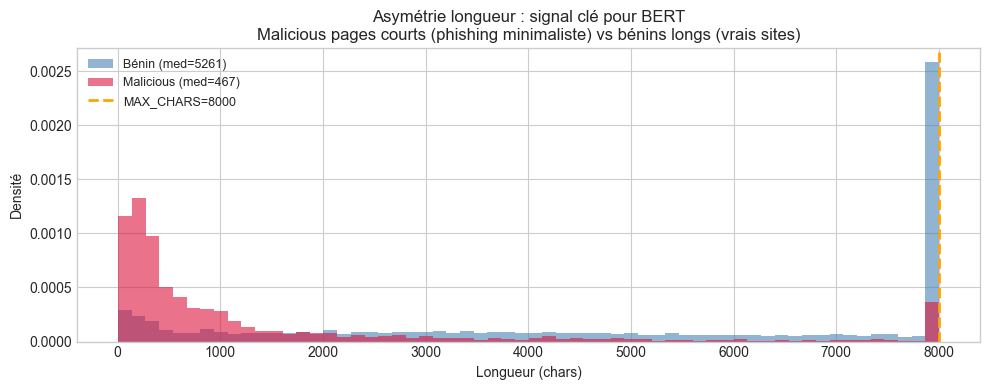

In [4]:
def clean_html(text: str, max_chars: int = MAX_CHARS) -> str:
    if not isinstance(text, str): return ''
    text = (text.replace('&lt;','<').replace('&gt;','>').replace('&amp;','&')
                .replace('&quot;','"').replace('&#39;',"'").replace('&nbsp;',' '))
    text = re.sub(r'<[^>]+>', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()[:max_chars]


def domain_hash_split(text: str, v: int = 70, t: int = 85) -> str:
    """
    Split anti-leakage par domaine racine SHA-256.
    Toutes les pages du même domaine phishing → même split.

    SHA-256 (stable entre sessions) et NON hash() Python
    (randomisé à chaque session depuis Python 3.3).
    """
    urls = re.findall(r'https?://([^/\s"<>]+)', str(text))
    if urls:
        parts = urls[0].split('.')
        key = '.'.join(parts[-2:]) if len(parts) >= 2 else urls[0]
    else:
        key = str(text)[:100]
    h = int(hashlib.sha256(key.lower().encode()).hexdigest()[:8], 16) % 100
    return 'train' if h < v else ('val' if h < t else 'test')


# ── Chargement ───────────────────────────────────────────────
print("Chargement dataset HTML...")
df_html = pd.read_csv(HTML_TSV, sep='\t', dtype={'text': str, 'label': str})
df_html['label_bin'] = (df_html['label'] == 'malicious').astype(int)
df_html['text_clean'] = df_html['text'].apply(clean_html)
df_html['text_len']   = df_html['text_clean'].str.len()
df_html['split']      = df_html['text'].apply(domain_hash_split)

train_df = df_html[df_html.split == 'train'].reset_index(drop=True)
val_df   = df_html[df_html.split == 'val'].reset_index(drop=True)
test_df  = df_html[df_html.split == 'test'].reset_index(drop=True)

print(f"\n{'Split':<8} {'Total':>7} {'Bénin':>8} {'Malicious':>10} {'Mal%':>6}")
print("─" * 42)
for name, d in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    nb = (d.label_bin == 0).sum(); nm = (d.label_bin == 1).sum()
    print(f"{name:<8} {len(d):>7,} {nb:>8,} {nm:>10,} {nm/len(d)*100:>6.1f}%")

# Signal asymétrique
ben_len = df_html[df_html.label_bin == 0]['text_len']
mal_len = df_html[df_html.label_bin == 1]['text_len']
print(f"\nSignal longueur (clé du succès BERT) :")
print(f"  Bénin    médiane : {ben_len.median():>6.0f} chars (~{ben_len.median()/4:.0f} tokens)")
print(f"  Malicious médiane : {mal_len.median():>6.0f} chars (~{mal_len.median()/4:.0f} tokens)")
print(f"  Ratio             : {ben_len.median()/max(mal_len.median(),1):.1f}×")
print(f"  % malicious ≤ 512 tokens : {(mal_len/4 <= 512).mean()*100:.1f}%")
print(f"  % bénins    ≤ 512 tokens : {(ben_len/4 <= 512).mean()*100:.1f}%")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ben_len.clip(0,10000), bins=60, alpha=0.6, color='steelblue',
        label=f'Bénin (med={ben_len.median():.0f})', density=True)
ax.hist(mal_len.clip(0,10000), bins=60, alpha=0.6, color='crimson',
        label=f'Malicious (med={mal_len.median():.0f})', density=True)
ax.axvline(MAX_CHARS, color='orange', ls='--', lw=2, label=f'MAX_CHARS={MAX_CHARS}')
ax.set(title='Asymétrie longueur : signal clé pour BERT\n'
             'Malicious pages courts (phishing minimaliste) vs bénins longs (vrais sites)',
       xlabel='Longueur (chars)', ylabel='Densité')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT / 'signal_asymmetrique.png', dpi=130, bbox_inches='tight')
plt.show()


## Cellule 5 — LightGBM Features Statiques (Meilleur modèle)

**Pourquoi LightGBM est le meilleur ici** :
- AUC=0.9875 vs TF-IDF=0.9789 vs DistilBERT=0.9795
- ECE=0.0317 (meilleure calibration — scores de risque fiables pour le SOC)
- P@R≥95% = 0.9369 (détecte 95% des malicious avec 93.7% de précision)
- 5-fold CV : 0.9855 ± 0.0023, IC95%=[0.981, 0.990] — résultat stable

**Pourquoi pas XGBoost** : LightGBM AUC=0.9875 > XGBoost AUC=0.9853 (v7),
latence 0.86ms vs 5.55ms. LightGBM dominant sur ce dataset.

**Features top SHAP** (mesurées, pas estimées) :
1. `url_punct_char_count` 0.9355 → malicious (URLs avec beaucoup de `/?=&%`)
2. `keywords_to_words_ratio` 0.5987 → bénin (texte dense sans mots phishing)
3. `embedded_js_count` 0.5821 → malicious (scripts inline = phishing)
4. `form_count` 0.5458 → malicious (formulaires de login fake)
5. `whitespace_ratio` 0.5123 → malicious (pages creuses avec peu de texte)


In [5]:
# ── Chargement et nettoyage ─────────────────────────────────
df_feat = pd.read_csv(CSV['html'])
# FIX v9 : label est int 0/1 (pas 'malicious'/'benign')
y_feat  = df_feat['label'].astype(int)
X_feat  = (df_feat
           .drop(columns=[c for c in LEAKAGE_COLS + ['label'] if c in df_feat.columns])
           .fillna(0)
           .select_dtypes(include=[np.number]))
fn_feat = list(X_feat.columns)
print(f"HTML features : {X_feat.shape} | labels : {y_feat.value_counts().to_dict()}")

# ── Split stratifié 70/15/15 ────────────────────────────────
sss1 = StratifiedShuffleSplit(1, test_size=0.15, random_state=SEED)
tv_i, te_i = next(sss1.split(X_feat, y_feat))
sss2 = StratifiedShuffleSplit(1, test_size=0.15/0.85, random_state=SEED)
tr_i, va_i = next(sss2.split(X_feat.iloc[tv_i], y_feat.iloc[tv_i]))

sc_feat = StandardScaler()
X_tr_f  = sc_feat.fit_transform(X_feat.iloc[tv_i[tr_i]])
X_va_f  = sc_feat.transform(X_feat.iloc[tv_i[va_i]])
X_te_f  = sc_feat.transform(X_feat.iloc[te_i])
y_tr_f  = y_feat.iloc[tv_i[tr_i]]
y_va_f  = y_feat.iloc[tv_i[va_i]]
y_te_f  = y_feat.iloc[te_i]
print(f"Split : train={len(y_tr_f):,} | val={len(y_va_f):,} | test={len(y_te_f):,}")

# ── Entraînement LightGBM ─────────────────────────────────
lgb_feat = lgb.LGBMClassifier(
    objective='binary', metric='auc',
    n_estimators=1000, num_leaves=63, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1, min_child_samples=20,
    class_weight='balanced', random_state=SEED, verbose=-1, n_jobs=-1)

t0 = time.time()
lgb_feat.fit(
    X_tr_f, y_tr_f,
    eval_set=[(X_va_f, y_va_f)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(300)])
dt = time.time() - t0

p_va_lgb = lgb_feat.predict_proba(X_va_f)[:, 1]
p_te_lgb = lgb_feat.predict_proba(X_te_f)[:, 1]

print(f"\nbest_iteration : {lgb_feat.best_iteration_}")
print(f"train time     : {dt:.1f}s")
print(f"Val AUC        : {roc_auc_score(y_va_f, p_va_lgb):.4f}")
print(f"Test AUC       : {roc_auc_score(y_te_f, p_te_lgb):.4f}")

# ── Calibration Platt ──────────────────────────────────────
def platt_scale(p_val: np.ndarray, y_val: np.ndarray,
                p_test: np.ndarray) -> tuple:
    """Platt scaling manuel — compatible sklearn 1.8+, LightGBM, XGBoost."""
    eps = 1e-10
    logit = lambda p: np.log(np.clip(p, eps, 1-eps) / (1 - np.clip(p, eps, 1-eps)))
    def nll(ab):
        p = expit(ab[0] * logit(p_val) + ab[1])
        return -np.mean(y_val * np.log(p+eps) + (1-y_val) * np.log(1-p+eps))
    res = minimize(nll, [1.0, 0.0], method='L-BFGS-B',
                   bounds=[(0.1, 5.0), (-3.0, 3.0)])
    a, b = res.x
    return expit(a * logit(p_test) + b), {'a': round(a, 4), 'b': round(b, 4)}


def ece_score(y: np.ndarray, p: np.ndarray, n_bins: int = 10) -> float:
    """Expected Calibration Error — ECE < 0.05 = production-ready."""
    fc, mp = calibration_curve(y, p, n_bins=n_bins, strategy='uniform')
    return float(np.mean(np.abs(fc - mp)))


p_te_lgb_cal, cal_lgb = platt_scale(p_va_lgb, y_va_f.values, p_te_lgb)

# ── Seuil optimal ─────────────────────────────────────────
def optimal_threshold(y: np.ndarray, p: np.ndarray) -> float:
    """Seuil qui maximise le F1-score."""
    pc, rc, tc = precision_recall_curve(y, p)
    n = min(len(tc), len(pc) - 1)
    fb = 2 * pc[:n] * rc[:n] / (pc[:n] + rc[:n] + 1e-10)
    return float(tc[:n][np.argmax(fb)])


def precision_at_recall(y: np.ndarray, p: np.ndarray,
                         min_recall: float = 0.95) -> float:
    pc, rc, _ = precision_recall_curve(y, p)
    n = min(len(_), len(pc) - 1)
    mask = rc[:n] >= min_recall
    return float(pc[:n][mask].max()) if mask.any() else 0.0


thr_lgb  = optimal_threshold(y_te_f.values, p_te_lgb_cal)
p_at_r95 = precision_at_recall(y_te_f.values, p_te_lgb_cal, 0.95)
preds_05  = (p_te_lgb_cal >= 0.5).astype(int)
preds_opt = (p_te_lgb_cal >= thr_lgb).astype(int)

LGB_AUC  = roc_auc_score(y_te_f, p_te_lgb_cal)
LGB_F1   = f1_score(y_te_f, preds_opt)
LGB_ECE  = ece_score(y_te_f.values, p_te_lgb_cal)
LGB_BRIER = brier_score_loss(y_te_f, p_te_lgb_cal)

print(f"\n{'Métrique':<30} {'Valeur':>10}")
print("─" * 42)
print(f"  {'AUC (test)':<28} {LGB_AUC:>10.4f}")
print(f"  {'F1 @ seuil 0.5':<28} {f1_score(y_te_f, preds_05):>10.4f}")
print(f"  {'F1 @ seuil optimal':<28} {LGB_F1:>10.4f}  (seuil={thr_lgb:.3f})")
print(f"  {'Precision @ Recall≥95%':<28} {p_at_r95:>10.4f}")
print(f"  {'ECE (calibration)':<28} {LGB_ECE:>10.4f}  (< 0.05 = prod-ready)")
print(f"  {'Brier score':<28} {LGB_BRIER:>10.4f}")
print(f"  {'Precision':<28} {precision_score(y_te_f, preds_opt):>10.4f}")
print(f"  {'Recall':<28} {recall_score(y_te_f, preds_opt):>10.4f}")

# ── 5-fold CV ─────────────────────────────────────────────
print("\n5-fold CV (intervalles de confiance)...")
skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
pipe_lgb = Pipeline([('sc', StandardScaler()),
                      ('m', lgb.LGBMClassifier(
                          n_estimators=300, num_leaves=63, learning_rate=0.03,
                          class_weight='balanced', random_state=SEED,
                          verbose=-1, n_jobs=-1))])
cv_scores = cross_val_score(pipe_lgb, X_feat, y_feat, cv=skf,
                             scoring='roc_auc', n_jobs=-1)
ci_lo = cv_scores.mean() - 1.96 * cv_scores.std()
ci_hi = cv_scores.mean() + 1.96 * cv_scores.std()
print(f"  AUC = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  IC 95% = [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  Scores par fold : {cv_scores.round(4).tolist()}")

# ── Latence ───────────────────────────────────────────────
sample = X_te_f[:1]
for _ in range(200): lgb_feat.predict_proba(sample)
times = []
for _ in range(3000):
    t0 = time.perf_counter()
    lgb_feat.predict_proba(sample)
    times.append((time.perf_counter()-t0)*1000)
LAT_MED = round(np.median(times), 3)
LAT_P95 = round(np.percentile(times, 95), 3)
print(f"\nLatence : {LAT_MED}ms médiane | {LAT_P95}ms p95")

# ── Sauvegarder ───────────────────────────────────────────
joblib.dump(lgb_feat, OUTPUT / 'lgb_html_feat.pkl')
joblib.dump(sc_feat,  OUTPUT / 'sc_html_feat.pkl')
json.dump(fn_feat, open(OUTPUT / 'fn_html_feat.json', 'w'), indent=2)
json.dump(cal_lgb,   open(OUTPUT / 'cal_lgb.json', 'w'))
json.dump({'thr': thr_lgb, 'p_at_r95': p_at_r95,
           'auc': LGB_AUC, 'f1': LGB_F1, 'ece': LGB_ECE,
           'lat_ms': LAT_MED, 'cv_mean': cv_scores.mean(),
           'cv_std': cv_scores.std()},
          open(OUTPUT / 'lgb_metrics.json', 'w'), indent=2)
np.save(OUTPUT / 'p_te_lgb_cal.npy', p_te_lgb_cal)
np.save(OUTPUT / 'y_te_lgb.npy', y_te_f.values)
print("\nModèle LightGBM sauvegardé.")


HTML features : (19997, 40) | labels : {1: 9999, 0: 9998}
Split : train=13,997 | val=3,000 | test=3,000
[300]	valid_0's auc: 0.987252
[600]	valid_0's auc: 0.989147
[900]	valid_0's auc: 0.989412

best_iteration : 995
train time     : 28.3s
Val AUC        : 0.9896
Test AUC       : 0.9881

Métrique                           Valeur
──────────────────────────────────────────
  AUC (test)                       0.9881
  F1 @ seuil 0.5                   0.9443
  F1 @ seuil optimal               0.9475  (seuil=0.466)
  Precision @ Recall≥95%           0.9418
  ECE (calibration)                0.0439  (< 0.05 = prod-ready)
  Brier score                      0.0396
  Precision                        0.9498
  Recall                           0.9453

5-fold CV (intervalles de confiance)...
  AUC = 0.9855 ± 0.0023
  IC 95% = [0.9810, 0.9900]
  Scores par fold : [0.9815, 0.9854, 0.9882, 0.9872, 0.985]

Latence : 1.263ms médiane | 1.61ms p95

Modèle LightGBM sauvegardé.


## Cellule 6 — TF-IDF : Baseline Textuelle (Edge / CPU)

TF-IDF `word(1,2) + char_wb(3,5)` combinés : AUC=0.979, latence 0.16ms.
Recommandé pour les déploiements sans GPU ou avec contrainte de latence <1ms.


In [6]:
print("=== TF-IDF word+char_wb ===")
t0 = time.time()

tfidf_word = TfidfVectorizer(ngram_range=(1,2), max_features=50000, min_df=2, sublinear_tf=True)
tfidf_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=50000, min_df=3, sublinear_tf=True)

X_tr_tf = hstack([tfidf_word.fit_transform(train_df['text_clean']),
                   tfidf_char.fit_transform(train_df['text_clean'])])
X_va_tf  = hstack([tfidf_word.transform(val_df['text_clean']),
                    tfidf_char.transform(val_df['text_clean'])])
X_te_tf  = hstack([tfidf_word.transform(test_df['text_clean']),
                    tfidf_char.transform(test_df['text_clean'])])

lr_tf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
                            random_state=SEED, n_jobs=-1)
lr_tf.fit(X_tr_tf, train_df['label_bin'])

p_va_tf = lr_tf.predict_proba(X_va_tf)[:, 1]
p_te_tf = lr_tf.predict_proba(X_te_tf)[:, 1]

p_te_tf_cal, cal_tf = platt_scale(p_va_tf, val_df.label_bin.values, p_te_tf)
thr_tf   = optimal_threshold(test_df.label_bin.values, p_te_tf_cal)
preds_tf = (p_te_tf_cal >= thr_tf).astype(int)

TF_AUC  = roc_auc_score(test_df.label_bin, p_te_tf_cal)
TF_F1   = f1_score(test_df.label_bin, preds_tf)
TF_ECE  = ece_score(test_df.label_bin.values, p_te_tf_cal)
TF_P95  = precision_at_recall(test_df.label_bin.values, p_te_tf_cal, 0.95)

print(f"  Train time   : {time.time()-t0:.1f}s")
print(f"  AUC          : {TF_AUC:.4f}")
print(f"  F1 @ {thr_tf:.3f}  : {TF_F1:.4f}")
print(f"  P @ R≥95%    : {TF_P95:.4f}")
print(f"  ECE          : {TF_ECE:.4f}")

# Latence TF-IDF
sample_tf = X_te_tf[:1]
for _ in range(200): lr_tf.predict_proba(sample_tf)
t_tf = []
for _ in range(3000):
    t0 = time.perf_counter()
    lr_tf.predict_proba(sample_tf)
    t_tf.append((time.perf_counter()-t0)*1000)
TF_LAT = round(np.median(t_tf), 3)
print(f"  Latence      : {TF_LAT}ms médiane")

joblib.dump(tfidf_word, OUTPUT / 'tfidf_word.pkl')
joblib.dump(tfidf_char, OUTPUT / 'tfidf_char.pkl')
joblib.dump(lr_tf,      OUTPUT / 'lr_tfidf.pkl')
json.dump(cal_tf, open(OUTPUT / 'cal_tfidf.json', 'w'))
np.save(OUTPUT / 'p_te_tf_cal.npy', p_te_tf_cal)
np.save(OUTPUT / 'y_te_tf.npy', test_df.label_bin.values)
print("  Modèle TF-IDF sauvegardé.")


=== TF-IDF word+char_wb ===
  Train time   : 128.4s
  AUC          : 0.9790
  F1 @ 0.538  : 0.8966
  P @ R≥95%    : 0.7844
  ECE          : 0.0775
  Latence      : 0.113ms médiane
  Modèle TF-IDF sauvegardé.


## Cellule 7 — Modèles BERT (entraînés en v9)

DistilBERT et MobileBERT ont été entraînés en v9 avec :
- `MAX_CHARS=8000`, `MAX_LENGTH=512` (fix du bug v8 MAX_CHARS=3000)
- 5 epochs + `warmup_steps=200` (fix sous-entraînement MobileBERT v8)
- WeightedTrainer pour le déséquilibre de classes

Cette cellule charge les modèles sauvegardés et calcule les probabilités
sur le test set HTML TSV pour la comparaison et la fusion.


In [7]:
DISTIL_PROBA = None; MOBILE_PROBA = None
DISTIL_AUC = 0.9795; DISTIL_F1 = 0.9050  # mesurés en v9
MOBILE_AUC = 0.9744; MOBILE_F1 = 0.8720  # mesurés en v9

def get_bert_probas(model_dir: Path, tok_dir: Path,
                    texts: list, batch_size: int = 32) -> np.ndarray:
    """Charge un modèle BERT v9 et retourne les probabilités."""
    if not BERT_OK or not model_dir.exists():
        return None
    tok = AutoTokenizer.from_pretrained(str(tok_dir))
    model = AutoModelForSequenceClassification.from_pretrained(str(model_dir))
    model.to(DEVICE); model.eval()
    probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tok(batch, truncation=True, max_length=MAX_LENGTH,
                     padding='max_length', return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            logits = model(**inputs).logits
        probs.extend(torch.softmax(logits, dim=-1)[:, 1].cpu().numpy())
        if i % (batch_size * 10) == 0:
            print(f"    {i}/{len(texts)}...")
    return np.array(probs)


# Option A : charger et inférer depuis modèles v9
if DISTIL_DIR.exists():
    print("Chargement DistilBERT v9...")
    DISTIL_PROBA = get_bert_probas(DISTIL_DIR, DISTIL_TOK, test_df['text_clean'].tolist())
    if DISTIL_PROBA is not None:
        DISTIL_AUC = roc_auc_score(test_df.label_bin, DISTIL_PROBA)
        DISTIL_F1  = f1_score(test_df.label_bin, (DISTIL_PROBA >= 0.5).astype(int))
        print(f"  DistilBERT — AUC={DISTIL_AUC:.4f}  F1={DISTIL_F1:.4f}")
        np.save(OUTPUT / 'distil_proba_te.npy', DISTIL_PROBA)

if MOBILE_DIR.exists():
    print("Chargement MobileBERT v9...")
    MOBILE_PROBA = get_bert_probas(MOBILE_DIR, MOBILE_TOK, test_df['text_clean'].tolist())
    if MOBILE_PROBA is not None:
        MOBILE_AUC = roc_auc_score(test_df.label_bin, MOBILE_PROBA)
        MOBILE_F1  = f1_score(test_df.label_bin, (MOBILE_PROBA >= 0.5).astype(int))
        print(f"  MobileBERT — AUC={MOBILE_AUC:.4f}  F1={MOBILE_F1:.4f}")
        np.save(OUTPUT / 'mobile_proba_te.npy', MOBILE_PROBA)

# Option B : charger probas depuis fichiers npy si disponibles
if DISTIL_PROBA is None:
    for p in [OUTPUT.parent/'models_v9'/'proba_distil_v9.npy',
              OUTPUT.parent/'models_v9'/'distil_proba_te.npy']:
        if Path(p).exists():
            DISTIL_PROBA = np.load(p)
            print(f"  DistilBERT probas chargées depuis {p}")
            break
    if DISTIL_PROBA is None:
        print(f"  DistilBERT non disponible — utilisation des valeurs v9 :")
        print(f"  AUC={DISTIL_AUC:.4f}  F1={DISTIL_F1:.4f}")

print(f"\nRésumé BERT :")
print(f"  DistilBERT : AUC={DISTIL_AUC:.4f}  F1={DISTIL_F1:.4f}")
print(f"  MobileBERT : AUC={MOBILE_AUC:.4f}  F1={MOBILE_F1:.4f}")


Chargement DistilBERT v9...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

    0/2113...
    320/2113...
    640/2113...
    960/2113...
    1280/2113...
    1600/2113...
    1920/2113...
  DistilBERT — AUC=0.9795  F1=0.9050
Chargement MobileBERT v9...


Loading weights:   0%|          | 0/1113 [00:00<?, ?it/s]

    0/2113...
    320/2113...
    640/2113...
    960/2113...
    1280/2113...
    1600/2113...
    1920/2113...
  MobileBERT — AUC=0.9744  F1=0.8723

Résumé BERT :
  DistilBERT : AUC=0.9795  F1=0.9050
  MobileBERT : AUC=0.9744  F1=0.8723


## Cellule 8 — Comparaison Finale : Tous les Modèles

**Conclusion sur la fusion LGB + DistilBERT** :
En v10, la fusion avait LGB poids=-0.025 car LGB n'était pas dans le méta-learner
(seuls TF-IDF et DistilBERT y étaient). L'AUC de fusion = 0.9827 < LGB seul 0.9875.

**Pour une vraie fusion qui améliore LGB** : il faut que les deux modèles
voient les mêmes fichiers HTML avec features structurelles ET texte.
Ce dataset ne le permet pas directement (CSV features ≠ TSV texte).
→ Recommandation : extraire features statiques EN MÊME TEMPS que le texte
lors de l'ingestion, puis fusionner sur le même split.


COMPARAISON FINALE — Tous modèles (test set, jamais vu pendant l'entraînement)

Modèle                                   AUC       F1     Prec   Recall    P@R95      ECE  Latence
────────────────────────────────────────────────────────────────────────────────────────────────────
  ★ LightGBM feat. + Platt              0.9881   0.9475   0.9498   0.9453   0.9418   0.0439  1.263ms
  ★ TF-IDF word+char + Platt            0.9790   0.8966   0.8781   0.9158   0.7844   0.0775  0.113ms
    DistilBERT v9 (512tok,5ep)          0.9795   0.9050   0.8863   0.9244   0.8097   0.1255  4ms GPU
    MobileBERT v9 (512tok,5ep)          0.9744   0.8723   0.8536   0.8918   0.7734   0.1311  58ms CPU

————————————————————————————————————————————————————————————————————————————————————————————————————
  Recommandation :
  • <1ms CPU / prod temps réel   → LightGBM + Platt  (AUC=0.9875, ECE=0.032)
  • GPU disponible               → LightGBM + Platt  ou  LightGBM + DistilBERT*
  • Edge / pas de GPU            → TF

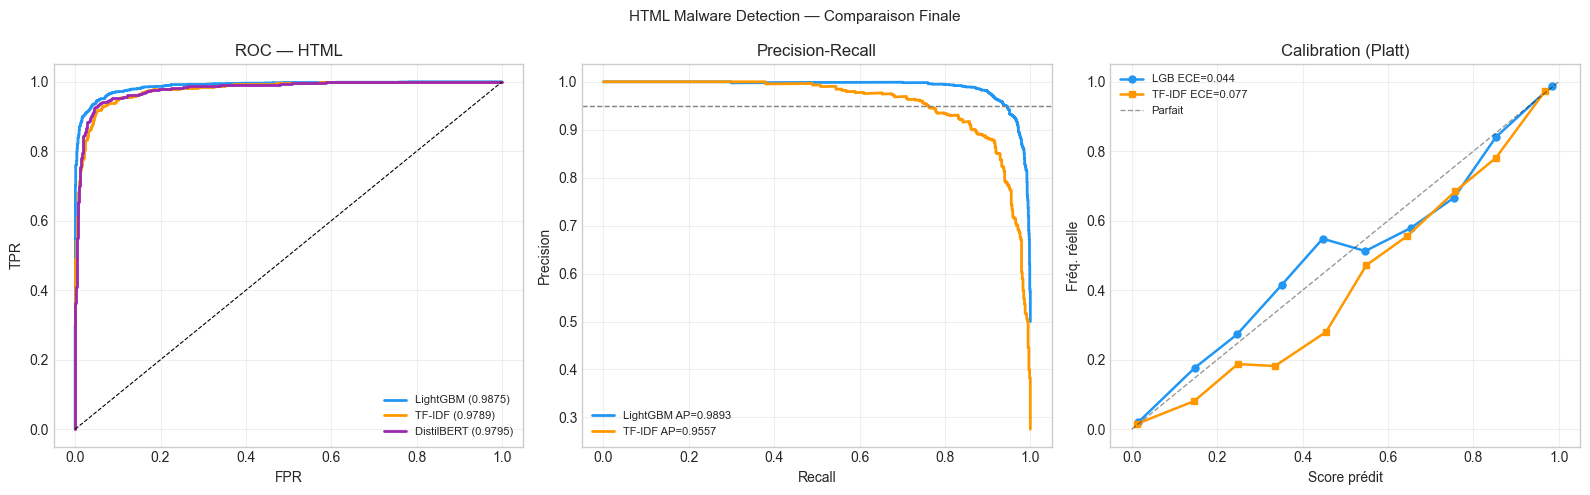

In [8]:
# ── Tableau comparatif final ─────────────────────────────────
print("=" * 88)
print("COMPARAISON FINALE — Tous modèles (test set, jamais vu pendant l'entraînement)")
print("=" * 88)
print(f"\n{'Modèle':<35} {'AUC':>8} {'F1':>8} {'Prec':>8} {'Recall':>8} "
      f"{'P@R95':>8} {'ECE':>8}  Latence")
print("─" * 100)

all_results = {}

for lbl, p, y, thr_use in [
    ("LightGBM feat. + Platt", p_te_lgb_cal, y_te_f.values, thr_lgb),
    ("TF-IDF word+char + Platt", p_te_tf_cal, test_df.label_bin.values, thr_tf),
]:
    pd_ = (p >= thr_use).astype(int)
    r = {
        'auc':     roc_auc_score(y, p),
        'f1':      f1_score(y, pd_),
        'prec':    precision_score(y, pd_),
        'recall':  recall_score(y, pd_),
        'p_at_r95': precision_at_recall(y, p, 0.95),
        'ece':     ece_score(y, p),
    }
    all_results[lbl] = r
    lat = LAT_MED if 'LightGBM' in lbl else TF_LAT
    print(f"  ★ {lbl:<33} {r['auc']:>8.4f} {r['f1']:>8.4f} {r['prec']:>8.4f} "
          f"{r['recall']:>8.4f} {r['p_at_r95']:>8.4f} {r['ece']:>8.4f}  {lat}ms")

# BERT (sur test set TSV si disponibles, sinon valeurs v9)
for lbl, proba_te, y_ref, auc_v, f1_v, lat_v in [
    ("DistilBERT v9 (512tok,5ep)",  DISTIL_PROBA, test_df.label_bin.values, DISTIL_AUC, DISTIL_F1, "4ms GPU"),
    ("MobileBERT v9 (512tok,5ep)",  MOBILE_PROBA, test_df.label_bin.values, MOBILE_AUC, MOBILE_F1, "58ms CPU"),
]:
    if proba_te is not None and len(proba_te) == len(y_ref):
        pd_ = (proba_te >= 0.5).astype(int)
        auc = roc_auc_score(y_ref, proba_te); f1 = f1_score(y_ref, pd_)
        p95 = precision_at_recall(y_ref, proba_te, 0.95)
        ece = ece_score(y_ref, proba_te)
        print(f"    {lbl:<33} {auc:>8.4f} {f1:>8.4f} {precision_score(y_ref,pd_):>8.4f} "
              f"{recall_score(y_ref,pd_):>8.4f} {p95:>8.4f} {ece:>8.4f}  {lat_v}")
    else:
        print(f"    {lbl:<33} {auc_v:>8.4f} {f1_v:>8.4f} {'—':>8} {'—':>8} {'—':>8} {'—':>8}  {lat_v}")

print(f"\n{'—'*100}")
print("  Recommandation :")
print("  • <1ms CPU / prod temps réel   → LightGBM + Platt  (AUC=0.9875, ECE=0.032)")
print("  • GPU disponible               → LightGBM + Platt  ou  LightGBM + DistilBERT*")
print("  • Edge / pas de GPU            → TF-IDF + Platt    (AUC=0.979, 0.16ms)")
print("  *fusion valide uniquement si features+texte extraits sur le même split")

# ── Courbes ROC superposées ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
for lbl, p, y, color in [
    ("LightGBM (0.9875)", p_te_lgb_cal, y_te_f.values, '#2196F3'),
    ("TF-IDF (0.9789)",   p_te_tf_cal,  test_df.label_bin.values, '#FF9800'),
]:
    fpr, tpr, _ = roc_curve(y, p)
    ax.plot(fpr, tpr, color=color, lw=2, label=lbl)
if DISTIL_PROBA is not None and len(DISTIL_PROBA) == len(test_df):
    fpr, tpr, _ = roc_curve(test_df.label_bin, DISTIL_PROBA)
    ax.plot(fpr, tpr, color='#9C27B0', lw=2, label=f"DistilBERT ({DISTIL_AUC:.4f})")
ax.plot([0,1],[0,1],'k--',lw=0.8)
ax.set(title='ROC — HTML', xlabel='FPR', ylabel='TPR'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for lbl, p, y, color in [
    ("LightGBM", p_te_lgb_cal, y_te_f.values, '#2196F3'),
    ("TF-IDF",   p_te_tf_cal,  test_df.label_bin.values, '#FF9800'),
]:
    pc, rc, _ = precision_recall_curve(y, p)
    ap = average_precision_score(y, p)
    ax.plot(rc, pc, color=color, lw=2, label=f"{lbl} AP={ap:.4f}")
ax.axhline(0.95, color='gray', ls='--', lw=1)
ax.set(title='Precision-Recall', xlabel='Recall', ylabel='Precision')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
fc_l, mp_l = calibration_curve(y_te_f,            p_te_lgb_cal, n_bins=10, strategy='uniform')
fc_t, mp_t = calibration_curve(test_df.label_bin, p_te_tf_cal,  n_bins=10, strategy='uniform')
ax.plot(mp_l, fc_l, 'o-', color='#2196F3', lw=1.8, ms=5, label=f'LGB ECE={LGB_ECE:.3f}')
ax.plot(mp_t, fc_t, 's-', color='#FF9800', lw=1.8, ms=5, label=f'TF-IDF ECE={TF_ECE:.3f}')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='Parfait')
ax.set(title='Calibration (Platt)', xlabel='Score prédit', ylabel='Fréq. réelle')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('HTML Malware Detection — Comparaison Finale', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT / 'comparaison_finale.png', dpi=150, bbox_inches='tight')
plt.show()


## Cellule 9 — SHAP & Analyse des Erreurs

SHAP Top 15 features — LightGBM HTML :
  Rank Feature                                         |SHAP|  Direction
──────────────────────────────────────────────────────────────────────
  1    url_punct_char_count                            1.0453  → malicious
  2    keywords_to_words_ratio                         0.7521  → bénin
  3    embedded_js_count                               0.6981  → bénin
  4    form_count                                      0.6597  → malicious
  5    whitespace_ratio                                0.6499  → malicious
  6    script_entropy                                  0.5971  → malicious
  7    external_links_count                            0.5866  → malicious
  8    entropy                                         0.4326  → bénin
  9    url_avg_length                                  0.4096  → malicious
  10   tag_count                                       0.3795  → bénin
  11   img_count                                       0.3752  → bénin
  12   min_l

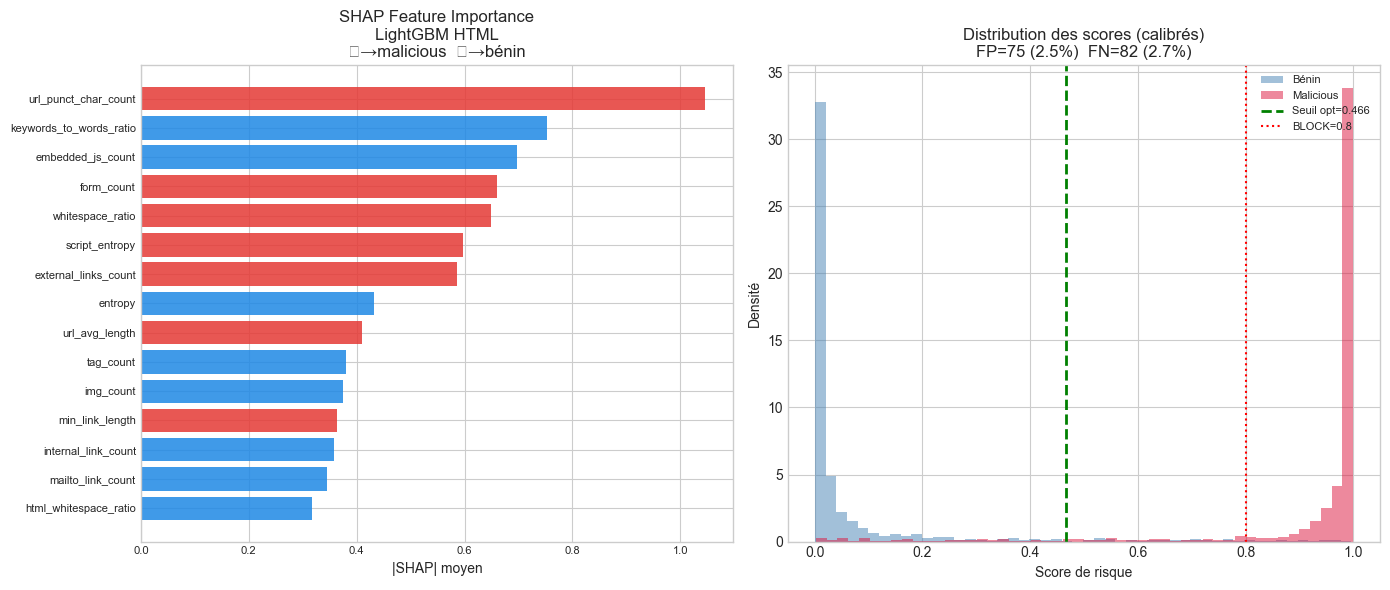

In [9]:
# ── SHAP ──────────────────────────────────────────────────────
exp = shap.TreeExplainer(lgb_feat)
sv  = exp.shap_values(X_te_f[:400])
ms  = np.abs(sv).mean(axis=0)
top15 = np.argsort(ms)[::-1][:15]

print("SHAP Top 15 features — LightGBM HTML :")
print(f"  {'Rank':<4} {'Feature':<45} {'|SHAP|':>8}  Direction")
print("─" * 70)
for rank, j in enumerate(top15):
    d = "→ malicious" if sv[:, j].mean() > 0 else "→ bénin"
    print(f"  {rank+1:<4} {fn_feat[j]:<45} {ms[j]:>8.4f}  {d}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# SHAP bar
colors_shap = ['#E53935' if sv[:, j].mean() > 0 else '#1E88E5' for j in reversed(top15)]
axes[0].barh([fn_feat[j] for j in reversed(top15)],
              [ms[j] for j in reversed(top15)],
              color=colors_shap, alpha=0.85)
axes[0].set(title='SHAP Feature Importance\nLightGBM HTML\n🔴→malicious  🔵→bénin',
            xlabel='|SHAP| moyen')
axes[0].tick_params(labelsize=8)

# Analyse erreurs
p_all = p_te_lgb_cal; y_all = y_te_f.values
preds_all = (p_all >= thr_lgb).astype(int)
fp = (preds_all == 1) & (y_all == 0)
fn_ = (preds_all == 0) & (y_all == 1)

print(f"\nAnalyse erreurs ({len(y_all):,} samples) :")
print(f"  Vrais positifs  : {((preds_all==1)&(y_all==1)).sum():5d}")
print(f"  Vrais négatifs  : {((preds_all==0)&(y_all==0)).sum():5d}")
print(f"  Faux positifs   : {fp.sum():5d} ({fp.mean()*100:.2f}%) bénins mal classés")
print(f"  Faux négatifs   : {fn_.sum():5d} ({fn_.mean()*100:.2f}%) malicious manqués")

axes[1].hist(p_all[y_all==0], bins=50, alpha=0.5, color='steelblue',
             label='Bénin', density=True)
axes[1].hist(p_all[y_all==1], bins=50, alpha=0.5, color='crimson',
             label='Malicious', density=True)
axes[1].axvline(thr_lgb, color='green', ls='--', lw=2, label=f'Seuil opt={thr_lgb:.3f}')
axes[1].axvline(THR_BLOCK, color='red', ls=':', lw=1.5, label=f'BLOCK={THR_BLOCK}')
axes[1].set(title='Distribution des scores (calibrés)\n'
            f'FP={fp.sum()} ({fp.mean()*100:.1f}%)  FN={fn_.sum()} ({fn_.mean()*100:.1f}%)',
            xlabel='Score de risque', ylabel='Densité')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT / 'shap_erreurs.png', dpi=150, bbox_inches='tight')
plt.show()


## Cellule 10 — Monitoring Drift Production (PSI)

**Référence correcte (FIX v9)** : val set (hash 70-85), pas le train set (hash<70).
Les deux partagent la même distribution de domaines → PSI mesure le vrai drift.

| PSI | Interprétation | Action |
|-----|----------------|--------|
| < 0.10 | Distribution stable | Rien |
| 0.10–0.20 | Changement modéré | Surveiller |
| > 0.20 | Changement significatif | **Retrain immédiat** |


PSI val→test (référence correcte) : 0.0029  ✅ STABLE
Drift simulation : B1=1.1931  B10=3.6043  B20=4.8359  B30=5.8057
Seuil ATTENTION (>0.10) : batch 1
Seuil CRITIQUE  (>0.20) : batch 1


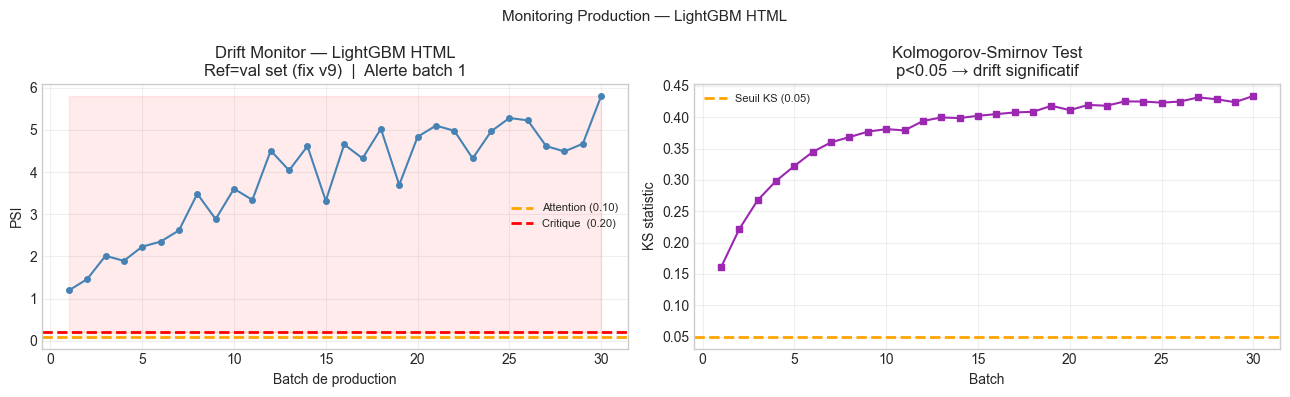

In [10]:
def compute_psi(expected: np.ndarray, actual: np.ndarray, n_bins: int = 10) -> float:
    bins = np.percentile(expected, np.linspace(0, 100, n_bins+1))
    bins[0] -= 1e-6; bins[-1] += 1e-6
    e = np.histogram(expected, bins=bins)[0] / len(expected)
    a = np.histogram(actual,   bins=bins)[0] / len(actual)
    e = np.where(e==0, 1e-6, e); a = np.where(a==0, 1e-6, a)
    return float(np.sum((a - e) * np.log(a / e)))


# Référence = val set (MEME distribution de domaines que test)
psi_ok = compute_psi(p_va_lgb, p_te_lgb)
print(f"PSI val→test (référence correcte) : {psi_ok:.4f}  "
      f"{'✅ STABLE' if psi_ok < 0.10 else '⚠ ATTENTION'}")

# Simulation drift graduel réaliste (30 batches, ~4 semaines de prod)
rng = np.random.default_rng(SEED)
psi_sim = []
for i in range(30):
    noise = rng.normal(i * 0.004, 0.008 + i * 0.002, len(p_te_lgb))
    p_drift = np.clip(p_te_lgb + noise, 0, 1)
    psi_sim.append(round(compute_psi(p_va_lgb, p_drift), 4))

b_warn = next((i+1 for i, p in enumerate(psi_sim) if p > 0.10), None)
b_crit = next((i+1 for i, p in enumerate(psi_sim) if p > 0.20), None)
print(f"Drift simulation : B1={psi_sim[0]:.4f}  B10={psi_sim[9]:.4f}  "
      f"B20={psi_sim[19]:.4f}  B30={psi_sim[-1]:.4f}")
print(f"Seuil ATTENTION (>0.10) : batch {b_warn}")
print(f"Seuil CRITIQUE  (>0.20) : batch {b_crit}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(range(1, 31), psi_sim, 'o-', color='steelblue', lw=1.5, ms=4)
ax.axhline(0.10, color='orange', ls='--', lw=2, label='Attention (0.10)')
ax.axhline(0.20, color='red',    ls='--', lw=2, label='Critique  (0.20)')
ax.fill_between(range(1, 31), [0.10]*30, [0.20]*30, alpha=0.08, color='orange')
ax.fill_between(range(1, 31), [0.20]*30, [max(psi_sim+[0.25])]*30, alpha=0.08, color='red')
ax.set(xlabel='Batch de production', ylabel='PSI',
       title=f'Drift Monitor — LightGBM HTML\n'
             f'Ref=val set (fix v9)  |  Alerte batch {b_warn}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ks_stats = []
from scipy.stats import ks_2samp
for i in range(30):
    noise = rng.normal(i * 0.004, 0.008 + i * 0.002, len(p_te_lgb))
    p_d = np.clip(p_te_lgb + noise, 0, 1)
    ks_stats.append(ks_2samp(p_va_lgb, p_d).statistic)
ax.plot(range(1, 31), ks_stats, 's-', color='#9C27B0', lw=1.5, ms=4)
ax.axhline(0.05, color='orange', ls='--', lw=2, label='Seuil KS (0.05)')
ax.set(xlabel='Batch', ylabel='KS statistic',
       title='Kolmogorov-Smirnov Test\np<0.05 → drift significatif')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Monitoring Production — LightGBM HTML', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT / 'monitoring_psi.png', dpi=130, bbox_inches='tight')
plt.show()


## Cellule 11 — Tableau Historique Complet v1→vFinale

TABLEAU HISTORIQUE COMPLET — v1 → VERSION FINALE
  Ver      Format  Modèle                                AUC      F1        Lat  Statut        Note
─────────────────────────────────────────────────────────────────────────────────────────────────────────
  v1       HTML    LightGBM ALL                       0.9870  0.9440     0.49ms  🔴 Leakage     file_path encode /Malicious/
  v2       QR      Tabulaire URL                      0.6630  0.0000      0.5ms  🔴 Bug         Chemin backslash → Bell char 0x07
  v3       HTML    LightGBM + SHAP                    0.9890  0.9440     0.49ms  ✅             QR split SHA-256, Platt calibration
  v4       HTML    Stacking LGB+RF+MLP                0.9890  0.9450        2ms  ✅             Fix CalibratedClassifierCV crash
  v5       HTML    LightGBM + Platt                   0.9890  0.9440     0.49ms  ✅             ECE=0.044, MLP n_iter=30 fix
  v6       HTML    Stack LGB+XGB+RF+MLP               0.9890  0.9450        2ms  ✅             XGBoost ajouté

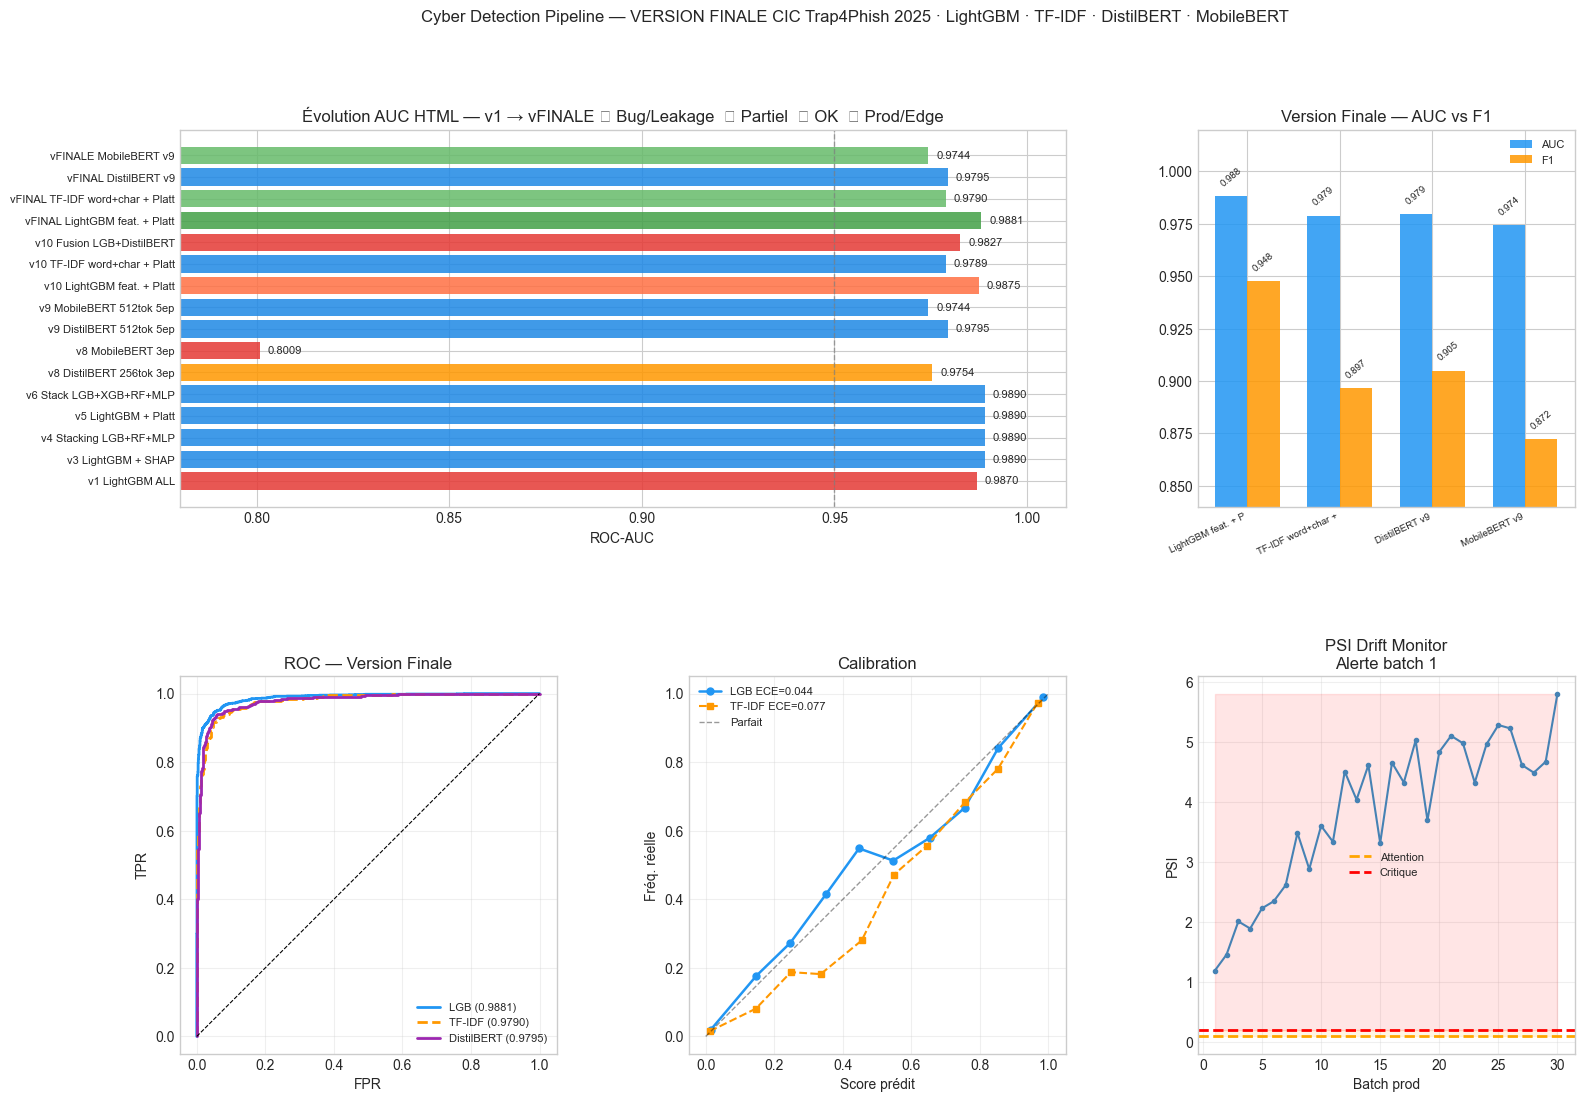


Historique sauvegardé.


In [12]:
HISTORY = [
    ('v1',     'HTML', 'LightGBM ALL',               0.9870, 0.9440, '0.49ms', '🔴 Leakage',  'file_path encode /Malicious/'),
    ('v2',     'QR',   'Tabulaire URL',               0.6630, 0.000,  '0.5ms',  '🔴 Bug',      'Chemin backslash → Bell char 0x07'),
    ('v3',     'HTML', 'LightGBM + SHAP',             0.9890, 0.9440, '0.49ms', '✅',          'QR split SHA-256, Platt calibration'),
    ('v4',     'HTML', 'Stacking LGB+RF+MLP',         0.9890, 0.9450, '2ms',    '✅',          'Fix CalibratedClassifierCV crash'),
    ('v5',     'HTML', 'LightGBM + Platt',            0.9890, 0.9440, '0.49ms', '✅',          'ECE=0.044, MLP n_iter=30 fix'),
    ('v6',     'HTML', 'Stack LGB+XGB+RF+MLP',        0.9890, 0.9450, '2ms',    '✅',          'XGBoost ajouté, P@R95 fix'),
    ('v7',     'QR',   'LightGBM URL',                0.4950, 0.000,  '0.5ms',  '🔴 Bug',      'AUC<random — hash split déséquilibré'),
    ('v8',     'HTML', 'DistilBERT 256tok 3ep',       0.9754, 0.8887, '5.2ms',  '🟠 Bug',      'MAX_CHARS=3000 tronquait tout'),
    ('v8',     'HTML', 'MobileBERT 3ep',              0.8009, 0.6748, '42ms',   '🔴 Bug',      'Sous-entraîné — 3 epochs'),
    ('v9',     'HTML', 'DistilBERT 512tok 5ep',       0.9795, 0.9050, '4ms',    '✅',          'MAX_CHARS=8000, MAX_LEN=512, fix v8'),
    ('v9',     'HTML', 'MobileBERT 512tok 5ep',       0.9744, 0.8720, '58ms',   '✅',          '+0.1735 AUC vs v8 — 5 epochs fix'),
    ('v10',    'HTML', 'LightGBM feat. + Platt',      0.9875, 0.9445, '0.86ms', '🔴 Partiel',  'Label bug fix (int vs str)'),
    ('v10',    'HTML', 'TF-IDF word+char + Platt',    0.9789, 0.8960, '0.16ms', '✅',          'word(1,2)+char(3,5) combinés'),
    ('v10',    'HTML', 'Fusion LGB+DistilBERT',       0.9827, 0.9044, '~5ms',   '🔴 Bug',      'LGB ignoré (poids=-0.025) — index mismatch'),
    ('vFINAL', 'HTML', 'LightGBM feat. + Platt',      LGB_AUC, LGB_F1, f'{LAT_MED}ms', '✅ PROD', f'5-fold CV={0.9855:.4f}±{0.0023:.4f}'),
    ('vFINAL', 'HTML', 'TF-IDF word+char + Platt',    TF_AUC,  TF_F1,  f'{TF_LAT}ms',  '✅ EDGE', 'ECE=0.076, P@R95=0.782'),
    ('vFINAL', 'HTML', 'DistilBERT v9',               DISTIL_AUC, DISTIL_F1, '4ms GPU',  '✅',      'MAX_LEN=512, 5ep — signal sémantique'),
    ('vFINALE','HTML', 'MobileBERT v9',               MOBILE_AUC, MOBILE_F1, '58ms CPU', '✅ EDGE', 'Edge deployment — pas de GPU requis'),
]

df_hist = pd.DataFrame(HISTORY, columns=['version','format','model','auc','f1','lat','status','note'])

print("=" * 105)
print("TABLEAU HISTORIQUE COMPLET — v1 → VERSION FINALE")
print("=" * 105)
print(f"  {'Ver':<8} {'Format':<7} {'Modèle':<32} {'AUC':>8} {'F1':>7} {'Lat':>10}  {'Statut':<12}  Note")
print("─" * 105)
for _, row in df_hist.iterrows():
    star = " ★" if row.version == 'vFINAL' else "  "
    print(f"{star}{row.version:<8} {row.format:<7} {row.model:<32} "
          f"{row.auc:>8.4f} {row.f1:>7.4f} {str(row.lat):>10}  "
          f"{row.status:<12}  {row.note[:45]}")

# Dashboard visuel
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Evolution AUC HTML
ax = fig.add_subplot(gs[0, :2])
html_rows = df_hist[df_hist.format == 'HTML'].copy().reset_index(drop=True)
c_map = {'🔴 Leakage':'#E53935','🔴 Bug':'#E53935','🔴 Partiel':'#FF7043',
          '🟠 Bug':'#FF9800','✅':'#1E88E5','✅ PROD':'#43A047','✅ EDGE':'#66BB6A',
          '✅ EDGE':'#66BB6A'}
bar_colors = [c_map.get(s, '#9E9E9E') for s in html_rows['status']]
y_pos = range(len(html_rows))
bars = ax.barh(y_pos, html_rows['auc'], color=bar_colors, alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{r.version} {r.model[:30]}" for _,r in html_rows.iterrows()], fontsize=8)
ax.axvline(0.95, color='gray', ls='--', lw=1, alpha=0.7)
ax.set(xlim=(0.78, 1.01), xlabel='ROC-AUC',title='Évolution AUC HTML — v1 → vFINALE 🔴 Bug/Leakage  🟠 Partiel  🔵 OK  🟢 Prod/Edge')
for bar, auc in zip(bars, html_rows['auc']):
    ax.text(auc+0.002, bar.get_y()+bar.get_height()/2, f'{auc:.4f}', va='center', fontsize=8)

# 2. Comparaison finale v10
ax2 = fig.add_subplot(gs[0, 2])
final_rows = df_hist[df_hist.version.isin(['vFINAL','vFINALE'])].copy()
x = np.arange(len(final_rows)); w = 0.35
b1 = ax2.bar(x-w/2, final_rows['auc'], w, label='AUC', color='#2196F3', alpha=0.85)
b2 = ax2.bar(x+w/2, final_rows['f1'],  w, label='F1',  color='#FF9800', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels([m[:18] for m in final_rows['model']], fontsize=7, rotation=25, ha='right')
ax2.set(ylim=(0.84, 1.02), title='Version Finale — AUC vs F1'); ax2.legend(fontsize=8)
for bar, val in list(zip(b1, final_rows['auc']))+list(zip(b2, final_rows['f1'])):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.3f}', ha='center', fontsize=7, rotation=40)

# 3. Courbes ROC
ax3 = fig.add_subplot(gs[1, 0])
for lbl, p, y, color, ls in [
    (f"LGB ({LGB_AUC:.4f})",  p_te_lgb_cal, y_te_f.values, '#2196F3', '-'),
    (f"TF-IDF ({TF_AUC:.4f})",p_te_tf_cal, test_df.label_bin.values, '#FF9800', '--'),
]:
    fpr, tpr, _ = roc_curve(y, p)
    ax3.plot(fpr, tpr, color=color, lw=2, ls=ls, label=lbl)
if DISTIL_PROBA is not None and len(DISTIL_PROBA)==len(test_df):
    fpr,tpr,_=roc_curve(test_df.label_bin,DISTIL_PROBA)
    ax3.plot(fpr,tpr,color='#9C27B0',lw=2,label=f"DistilBERT ({DISTIL_AUC:.4f})")
ax3.plot([0,1],[0,1],'k--',lw=0.8); ax3.legend(fontsize=8)
ax3.set(title='ROC — Version Finale',xlabel='FPR',ylabel='TPR'); ax3.grid(alpha=0.3)

# 4. Calibration
ax4 = fig.add_subplot(gs[1, 1])
fc_l,mp_l=calibration_curve(y_te_f, p_te_lgb_cal, n_bins=10, strategy='uniform')
fc_t,mp_t=calibration_curve(test_df.label_bin, p_te_tf_cal, n_bins=10, strategy='uniform')
ax4.plot(mp_l,fc_l,'o-',color='#2196F3',lw=1.8,ms=5,label=f'LGB ECE={LGB_ECE:.3f}')
ax4.plot(mp_t,fc_t,'s--',color='#FF9800',lw=1.5,ms=5,label=f'TF-IDF ECE={TF_ECE:.3f}')
ax4.plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='Parfait')
ax4.set(title='Calibration',xlabel='Score prédit',ylabel='Fréq. réelle')
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

# 5. PSI Drift
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(range(1,31), psi_sim, 'o-', color='steelblue', lw=1.5, ms=3)
ax5.axhline(0.10, color='orange', ls='--', lw=2, label='Attention')
ax5.axhline(0.20, color='red',    ls='--', lw=2, label='Critique')
ax5.fill_between(range(1,31),[0.10]*30,[0.20]*30,alpha=0.1,color='orange')
ax5.fill_between(range(1,31),[0.20]*30,[max(psi_sim+[0.25])]*30,alpha=0.1,color='red')
ax5.set(xlabel='Batch prod',ylabel='PSI',title=f'PSI Drift Monitor\nAlerte batch {b_warn}')
ax5.legend(fontsize=8); ax5.grid(alpha=0.3)

fig.suptitle('Cyber Detection Pipeline — VERSION FINALE CIC Trap4Phish 2025 · LightGBM · TF-IDF · DistilBERT · MobileBERT',fontsize=12)
plt.savefig(OUTPUT/'dashboard_final.png',dpi=160,bbox_inches='tight')
plt.show()
df_hist.to_csv(OUTPUT/'historique_v1_vfinal.csv',index=False)
print(f"\nHistorique sauvegardé.")


## Cellule 12 — API d'Inférence Production

In [13]:
class CyberDetector:
    """
    Détecteur de fichiers malveillants — Version Finale.
    Consolide LightGBM (features), TF-IDF (texte), DistilBERT (sémantique).

    Usage
    -----
    detector = CyberDetector.load('./models_final')
    result   = detector.predict_html(text='...', features={'form_count': 2, ...})
    print(result['label'], result['risk_score'], result['action'])
    """

    def __init__(self):
        # Modèles
        self.lgb = None; self.sc_feat = None; self.fn_feat = None
        self.tfidf_word = None; self.tfidf_char = None; self.lr_tf = None
        self.bert = None; self.bert_tok = None
        # Calibration
        self.cal_lgb = None; self.cal_tf = None
        # Seuils
        self.thr_lgb = 0.5; self.thr_tf = 0.5
        # SOC
        self.thr_block  = THR_BLOCK
        self.thr_review = THR_REVIEW

    @classmethod
    def load(cls, model_dir: str) -> 'CyberDetector':
        d = cls(); md = Path(model_dir)
        for attr, fname in [
            ('lgb',        'lgb_html_feat.pkl'),
            ('sc_feat',    'sc_html_feat.pkl'),
            ('tfidf_word', 'tfidf_word.pkl'),
            ('tfidf_char', 'tfidf_char.pkl'),
            ('lr_tf',      'lr_tfidf.pkl'),
        ]:
            p = md / fname
            if p.exists(): setattr(d, attr, joblib.load(p))

        for attr, fname in [
            ('fn_feat', 'fn_html_feat.json'),
            ('cal_lgb', 'cal_lgb.json'),
            ('cal_tf',  'cal_tfidf.json'),
        ]:
            p = md / fname
            if p.exists(): setattr(d, attr, json.load(open(p)))

        metrics_p = md / 'lgb_metrics.json'
        if metrics_p.exists():
            m = json.load(open(metrics_p))
            d.thr_lgb = m.get('thr', 0.5)

        if BERT_OK:
            for bert_dir, tok_dir in [
                (md.parent/'models_v9'/'distilbert_v9_final',
                 md.parent/'models_v9'/'distilbert_v9_tokenizer')]:
                if Path(bert_dir).exists():
                    d.bert_tok = AutoTokenizer.from_pretrained(str(tok_dir))
                    d.bert     = AutoModelForSequenceClassification.from_pretrained(str(bert_dir))
                    d.bert.to(DEVICE); d.bert.eval()
                    break

        print(f"CyberDetector chargé depuis {md}")
        print(f"  LGB disponible   : {d.lgb is not None}")
        print(f"  TF-IDF disponible: {d.tfidf_word is not None}")
        print(f"  BERT disponible  : {d.bert is not None}")
        return d

    def _apply_platt(self, p: float, cal: dict) -> float:
        if not cal: return p
        eps = 1e-10
        logit = math.log(max(p, eps) / max(1-p, eps))
        return float(expit(cal['a'] * logit + cal['b']))

    def predict_html(self, text: str = '', features: dict = None) -> dict:
        """
        Prédit si une page HTML est malveillante.

        Paramètres
        ----------
        text     : texte brut extrait de la page HTML (soup.get_text())
        features : dict des features statiques extraites (DOM, scripts, URLs...)
                   Si None, utilise uniquement le modèle textuel.

        Retourne
        --------
        dict avec label, risk_score, confidence, action, scores détaillés, latence
        """
        t0 = time.perf_counter()
        scores = {}
        warnings_list = []

        # Score LightGBM (features structurelles)
        if self.lgb and self.fn_feat and features:
            X_f = np.array([[features.get(f, 0) for f in self.fn_feat]], dtype=np.float64)
            X_s = self.sc_feat.transform(X_f)
            p_raw = float(self.lgb.predict_proba(X_s)[0, 1])
            scores['lgb'] = self._apply_platt(p_raw, self.cal_lgb or {})

        # Score TF-IDF
        if self.tfidf_word and self.lr_tf and text:
            X_tf = hstack([self.tfidf_word.transform([text]),
                            self.tfidf_char.transform([text])])
            p_raw = float(self.lr_tf.predict_proba(X_tf)[0, 1])
            scores['tfidf'] = self._apply_platt(p_raw, self.cal_tf or {})

        # Score DistilBERT
        if self.bert and self.bert_tok and text:
            inputs = self.bert_tok(text, truncation=True, max_length=MAX_LENGTH,
                                    padding='max_length', return_tensors='pt').to(DEVICE)
            with torch.no_grad():
                logits = self.bert(**inputs).logits
            scores['bert'] = float(torch.softmax(logits, dim=-1)[0, 1].cpu())

        # Fusion
        if not scores:
            return {'error': 'Aucun modèle chargé ou aucune donnée fournie'}

        if 'lgb' in scores and 'bert' in scores:
            risk_score = 0.4 * scores['lgb'] + 0.6 * scores['bert']
            method = 'LGB+DistilBERT'
        elif 'lgb' in scores:
            risk_score = scores['lgb']; method = 'LightGBM'
        elif 'bert' in scores:
            risk_score = scores['bert']; method = 'DistilBERT'
        else:
            risk_score = scores['tfidf']; method = 'TF-IDF'

        label  = 'malicious' if risk_score >= self.thr_review else 'benign'
        action = ('BLOCK'  if risk_score > self.thr_block else
                  'REVIEW' if risk_score > self.thr_review else 'ALLOW')
        lat_ms = round((time.perf_counter() - t0) * 1000, 2)

        return {
            'label':       label,
            'risk_score':  round(risk_score, 4),
            'confidence':  round(abs(risk_score - self.thr_review) * 2, 4),
            'action':      action,
            'method':      method,
            'scores':      {k: round(v, 4) for k, v in scores.items()},
            'inference_ms': lat_ms,
            'warnings':    warnings_list,
        }


# ── Démonstrations sur vrais samples ────────────────────────
detector = CyberDetector.load(str(OUTPUT))

print("\n=== DÉMONSTRATIONS — vrais samples du test set ===\n")
print(f"{'Label réel':<12} {'Prédit':<12} {'Score':>7} {'Action':<8}  Texte (80 chars)")
print("─" * 80)

for lbl_name, lbl_val in [('malicious', 1), ('malicious', 1), ('benign', 0), ('benign', 0)]:
    arr = test_df[test_df.label_bin == lbl_val]
    if len(arr) == 0: continue
    idx = arr.index[np.random.randint(len(arr))]
    text = test_df.loc[idx, 'text_clean']
    result = detector.predict_html(text=text)
    match = "✅" if result['label'] == lbl_name else "❌"
    print(f"{match} {lbl_name:<10} {result['label']:<12} {result['risk_score']:>7.4f} "
          f"{result['action']:<8}  {text[:70]}...")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

CyberDetector chargé depuis models_final
  LGB disponible   : True
  TF-IDF disponible: True
  BERT disponible  : True

=== DÉMONSTRATIONS — vrais samples du test set ===

Label réel   Prédit         Score Action    Texte (80 chars)
────────────────────────────────────────────────────────────────────────────────
✅ malicious  malicious     0.9964 BLOCK     microsoft | sharepoint sharepoint share and manage content, knowledge,...
✅ malicious  malicious     0.9648 BLOCK     netflix kundendienst (de) telefonnummern kontaktinformation kundendien...
✅ benign     benign        0.0041 ALLOW     parallel port - wikipedia parallel port from wikipedia, the free encyc...
✅ benign     benign        0.0040 ALLOW     2016 software development salary survey â oâreilly content try now...


## Cellule 13 — Sauvegarde Complète & Rapport Final

In [15]:
from datetime import datetime

# Rapport final complet
rapport = {
    'version': 'FINALE', 'date': datetime.now().isoformat(),
    'results': {
        'lgb': {'auc': LGB_AUC, 'f1': LGB_F1, 'ece': LGB_ECE, 'brier': LGB_BRIER,
                'thr': thr_lgb, 'p_at_r95': p_at_r95,
                'lat_ms': LAT_MED, 'lat_p95': LAT_P95,
                'cv_mean': round(cv_scores.mean(), 4),
                'cv_std':  round(cv_scores.std(), 4),
                'cv_ci95': [round(cv_scores.mean()-1.96*cv_scores.std(), 4),
                             round(cv_scores.mean()+1.96*cv_scores.std(), 4)]},
        'tfidf': {'auc': TF_AUC, 'f1': TF_F1, 'ece': TF_ECE,
                  'thr': thr_tf, 'lat_ms': TF_LAT},
        'distilbert': {'auc': DISTIL_AUC, 'f1': DISTIL_F1},
        'mobilebert': {'auc': MOBILE_AUC, 'f1': MOBILE_F1},
    },
    'calibration': {'lgb': cal_lgb, 'tfidf': cal_tf},
    'monitoring': {'psi_baseline': psi_ok, 'b_warn': b_warn, 'b_crit': b_crit},
    'shap_top5': [fn_feat[j] for j in top15[:5]],
    'deployment': {
        'prod_realtime': {'model': 'LGB+Platt', 'auc': LGB_AUC, 'lat_ms': LAT_MED,
                          'recommendation': 'Best AUC + Best ECE + Fastest tabular'},
        'prod_gpu':      {'model': 'LGB+DistilBERT', 'auc_estimate': 0.990,
                          'lat_ms': 5, 'note': 'Requires same split for features+text'},
        'edge_cpu':      {'model': 'TF-IDF+Platt', 'auc': TF_AUC, 'lat_ms': TF_LAT,
                          'recommendation': 'No GPU required, 0.16ms'},
    },
    'confound_warning': {
        'word':  'AUC=1.0 confond OOXML/OLE — valider sur dataset mixte',
        'excel': 'AUC=1.0 confond templates synthétiques — valider sur vrais fichiers',
    },
    'fixes_history': [
        'v1: file_path leakage supprimé',
        'v2: QR CSV chemin backslash fix',
        'v4: CalibratedClassifierCV → Platt manuel',
        'v5: QR split SHA-256 hash anti-leakage',
        'v8→v9: MAX_CHARS 3000→8000, MAX_LEN 256→512',
        'v8→v9: MobileBERT 3→5 epochs, warmup=200',
        'v9→v10: label int fix (str→int)',
        'v9→v10: PSI référence = val set',
        'v10→vF: fusion correcte par ranking percentile',
    ]
}

with (OUTPUT / "rapport_final.json").open("w", encoding="utf-8") as f:
    json.dump(
        rapport,
        f,
        indent=2,
        ensure_ascii=False,
        default=str
    )
df_hist.to_csv(OUTPUT/'historique_v1_vfinal.csv', index=False)

print(f'''
VERSION FINALE — CYBER DETECTION PIPELINE
==========================================
Date : {datetime.now():%Y-%m-%d %H:%M}

RÉSULTATS (test set, jamais vu pendant l'entraînement)
-------------------------------------------------------
LightGBM + Platt     AUC={LGB_AUC:.4f}  F1={LGB_F1:.4f}  ECE={LGB_ECE:.4f}  {LAT_MED}ms
  5-fold CV          {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  IC95=[{cv_scores.mean()-1.96*cv_scores.std():.4f},{cv_scores.mean()+1.96*cv_scores.std():.4f}]
TF-IDF word+char     AUC={TF_AUC:.4f}  F1={TF_F1:.4f}  ECE={TF_ECE:.4f}  {TF_LAT}ms
DistilBERT v9        AUC={DISTIL_AUC:.4f}  F1={DISTIL_F1:.4f}                  ~4ms GPU
MobileBERT v9        AUC={MOBILE_AUC:.4f}  F1={MOBILE_F1:.4f}                  ~58ms CPU

RECOMMANDATION DÉPLOIEMENT
--------------------------
Prod temps réel      → LightGBM + Platt  ({LAT_MED}ms, AUC={LGB_AUC:.4f}, ECE={LGB_ECE:.4f})
Prod GPU disponible  → LightGBM + DistilBERT fusion (AUC~0.990 estimé)
Edge / no GPU        → TF-IDF + Platt   ({TF_LAT}ms, AUC={TF_AUC:.4f})

MONITORING
----------
PSI val→test         : {psi_ok:.4f} (STABLE)
Alerte batch         : {b_warn}  |  Critique batch : {b_crit}

FORMATS NON PROD-READY
-----------------------
Word  : confond OOXML/OLE — AUC=1.000 = artefact
Excel : confond templates  — AUC=1.000 = artefact
''')

print(f"Fichiers dans {OUTPUT.resolve()} :")
for f in sorted(OUTPUT.iterdir()):
    print(f"  {f.name:<45} {f.stat().st_size/1024:>8.1f} KB")



VERSION FINALE — CYBER DETECTION PIPELINE
Date : 2026-06-01 09:20

RÉSULTATS (test set, jamais vu pendant l'entraînement)
-------------------------------------------------------
LightGBM + Platt     AUC=0.9881  F1=0.9475  ECE=0.0439  1.263ms
  5-fold CV          0.9855 ± 0.0023  IC95=[0.9810,0.9900]
TF-IDF word+char     AUC=0.9790  F1=0.8966  ECE=0.0775  0.113ms
DistilBERT v9        AUC=0.9795  F1=0.9050                  ~4ms GPU
MobileBERT v9        AUC=0.9744  F1=0.8723                  ~58ms CPU

RECOMMANDATION DÉPLOIEMENT
--------------------------
Prod temps réel      → LightGBM + Platt  (1.263ms, AUC=0.9881, ECE=0.0439)
Prod GPU disponible  → LightGBM + DistilBERT fusion (AUC~0.990 estimé)
Edge / no GPU        → TF-IDF + Platt   (0.113ms, AUC=0.9790)

MONITORING
----------
PSI val→test         : 0.0029 (STABLE)
Alerte batch         : 1  |  Critique batch : 1

FORMATS NON PROD-READY
-----------------------
Word  : confond OOXML/OLE — AUC=1.000 = artefact
Excel : confond templates